In [2]:
import numpy as np
import matplotlib.pyplot as plt

Exponentially decaying kernel which can be simulated by Markovian Embedding    
Every mode of the kernel is parametrized by a friction $\gamma_i$ and memory time $\tau_i$    
Full kernel given by:   

\begin{equation}
\Gamma(t) = \sum_i \frac{\gamma_i}{\tau_i} e^{-t / \tau_i}
\end{equation}

In [3]:
# Evaluating the reference kernels

def get_kernel_ref(time, gammas, taus):
    output = np.zeros_like(time)
    for gamma, tau in zip(gammas, taus):
        output += gamma / tau * np.exp(-time / tau)
    return output

def get_kernel_integral_ref(time, gammas, taus):
    output = np.zeros_like(time)
    for gamma, tau in zip(gammas, taus):
        output += gamma * (1 - np.exp(-time / tau))
    return output

In [4]:
# set up parameters for simulation in harmonic potential
gammas = np.array([1000.])
taus = np.array([1.0])
ks = gammas / taus
dt = 2e-3
# here, I use a harmonic potential
kharm = 120.0
mass = 17.0
kbt = 2.494

In [5]:
import numpy as np
import matplotlib.pyplot as plt
#from numba import njit
from scipy.stats import norm

def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    # which one to conjugate should not matter if data is converged
    corr = np.fft.ifft(b_fft * np.conj(a_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

#@njit
def get_state_update(x, v, ys, kny, dt, k, m, gammas, ks, fr):
    """Get state update for markovian embedding with exp kernel."""
    update_x = dt * v
    update_v = -k * x
    for i in range(len(gammas)):
        update_v += ks[i] * (ys[i] - x)
        kny[i] = dt * ks[i] / gammas[i] * (x - ys[i]) + fr[i]
    update_v *= dt / m
    return update_x, update_v


#@njit
def integrate_euler(x0, v0, steps, dt, kbt, m, k, gammas, ks):
    """Integrate using Euler Maruyama"""
    traj = np.zeros(steps + 1)
    traj[0] = x0
    vel = v0
    ys = np.zeros(len(gammas))
    for i in range(len(gammas)):
        if ks[i] > 0.0:
            ys[i] = x0 + np.sqrt(kbt / ks[i]) * np.random.normal()
    prefac_fr = np.sqrt(2 * kbt * dt / gammas)
    fr = np.zeros(len(gammas))
    k1y = np.zeros(len(gammas))
    for i in range(steps):
        for j in range(len(gammas)):
            fr[j] = prefac_fr[j] * np.random.normal()
        k1x, k1v = get_state_update(traj[i], vel, ys, k1y, dt, k, m, gammas, ks, fr)
        traj[i + 1] = traj[i] + k1x
        for j in range(len(gammas)):
            ys[j] += k1y[j]
        vel += k1v
    return traj


#@njit
def update_temp_array(ys, kn_y, temp_y, factor):
    """Update temp arrays that hold y + ky1/2 / 2. or y + ky3."""
    for j in range(len(kn_y)):
        temp_y[j] = ys[j] + factor * kn_y[j]


#@njit
def integrate_rk4(x0, v0, steps, dt, kbt, m, k, gammas, ks):
    """Integrate using Euler Maruyama"""
    traj = np.zeros(steps + 1)
    traj[0] = x0
    vel = v0
    ys = np.zeros(len(gammas))
    for i in range(len(gammas)):
        if ks[i] > 0.0:
            ys[i] = x0 + np.sqrt(kbt / ks[i]) * np.random.normal()
    prefac_fr = np.sqrt(2 * kbt * dt / gammas)
    fr = np.zeros(len(gammas))
    k1y = np.zeros(len(gammas))
    k2y = np.zeros(len(gammas))
    k3y = np.zeros(len(gammas))
    k4y = np.zeros(len(gammas))
    temp_y = np.zeros(len(gammas))
    for i in range(steps):
        for j in range(len(gammas)):
            fr[j] = prefac_fr[j] * np.random.normal()
        k1x, k1v = get_state_update(traj[i], vel, ys, k1y, dt, k, m, gammas, ks, fr)
        update_temp_array(ys, k1y, temp_y, 0.5)
        k2x, k2v = get_state_update(
            traj[i] + k1x / 2.0, vel + k1v / 2.0, temp_y, k2y, dt, k, m, gammas, ks, fr
        )
        update_temp_array(ys, k2y, temp_y, 0.5)
        k3x, k3v = get_state_update(
            traj[i] + k2x / 2.0, vel + k2v / 2.0, temp_y, k3y, dt, k, m, gammas, ks, fr
        )
        update_temp_array(ys, k3y, temp_y, 1.0)
        k4x, k4v = get_state_update(traj[i] + k3x, vel + k3v, temp_y, k4y, dt, k, m, gammas, ks, fr)
        traj[i + 1] = traj[i] + (k1x + 2.0 * k2x + 2.0 * k3x + k4x) / 6.0
        vel += (k1v + 2.0 * k2v + 2.0 * k3v + k4v) / 6.0
        for j in range(len(gammas)):
            ys[j] += (k1y[j] + 2.0 * k2y[j] + 2.0 * k3y[j] + k4y[j]) / 6.0
    return traj

steps = int(1e7)
x0 = np.sqrt(kbt / kharm) * np.random.normal()
v0 = np.sqrt(kbt / mass) * np.random.normal()

# Integrating the Coupled Langevin Eqs with embedded Kernel
traj = integrate_rk4(x0, v0, steps, dt, kbt, mass, kharm, gammas, ks)

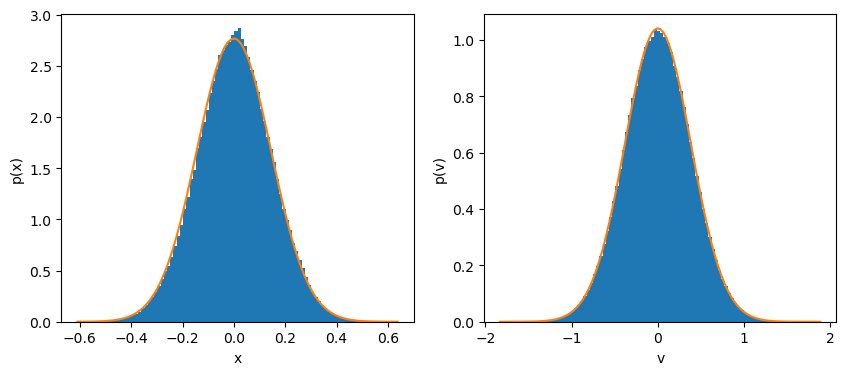

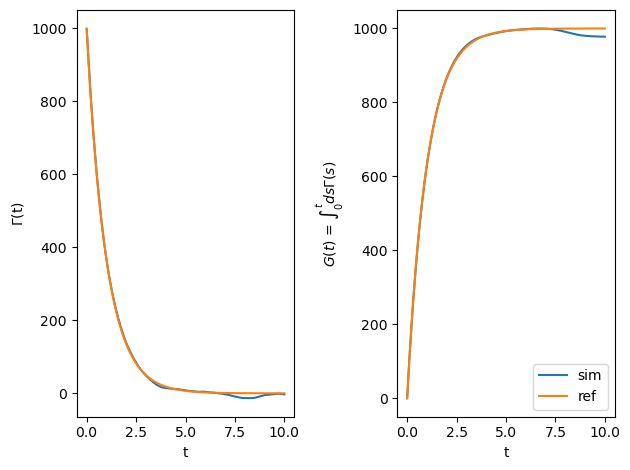

In [6]:
#@njit
def g_method_xdu_nomass(vv_corr, xdu_corr, dt, trunc):
    """Compute the integral over the kernel."""
    trunc = int(min([len(vv_corr), len(xdu_corr), trunc]))
    kernel_i = np.zeros(trunc)
    prefac = 2.0 / vv_corr[0]
    for i in range(1, trunc):
        kernel_i[i] = prefac * (
            (xdu_corr[i] - vv_corr[i] * xdu_corr[0] / vv_corr[0]) / dt
            - np.sum(kernel_i[1:i] * vv_corr[1:i][::-1])
        )
    return kernel_i


def plot_dists(traj, dt, kbt, mass, k, title=None):
    """Compare distributions to Gaussian reference."""
    _fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    _hist, vals, _ = axes[0].hist(traj, bins=100, density=True)
    # ref_pot = np.exp(-U0 * (vals ** 2 - 1) ** 2 / kT)
    # axes[0].plot(vals, ref_pot / np.trapz(ref_pot, vals), label="ref")
    axes[0].set_title(title)
    axes[0].plot(vals, norm.pdf(vals, scale=np.sqrt(kbt / k)))
    axes[0].set(xlabel="x", ylabel="p(x)")
    vel = np.diff(traj) / dt
    _hist, vals, _ = axes[1].hist(vel, bins=100, density=True)
    axes[1].plot(vals, norm.pdf(vals, scale=np.sqrt(kbt / mass)))
    axes[1].set(xlabel="v", ylabel="p(v)")
    plt.show()


def plot_kernel(traj, dt, kharm, kbt, gammas, taus):
    """Compute kernel and compare to reference."""
    trunc = int(10 / dt)
    vel = np.diff(traj) / dt
    vv_corr = correlation_fft(vel, vel, trunc)
    del vel
    # we could use this, more accurate: du = kharm * traj
    # for arbitrary potential
    hist_x, bins = np.histogram(traj, bins=150)
    bins = 0.5 * (bins[1:] + bins[:-1])
    fe = -kbt * np.log(hist_x)
    grad_fe = np.gradient(fe, bins) 
    du = np.interp(traj, bins, grad_fe)
    xdu_corr = correlation_fft(traj, du, trunc)
    kernel_int = g_method_xdu_nomass(
        trunc=trunc,
        dt=dt,
        vv_corr=vv_corr,
        xdu_corr=xdu_corr,
    )
    _fig, axes = plt.subplots(1, 2)
    time = np.arange(trunc) * dt
    kernel_ref = get_kernel_ref(time, gammas, taus)
    kernel_int_ref = get_kernel_integral_ref(time, gammas, taus)
    axes[0].plot(time, np.gradient(kernel_int, dt), label="sim")
    axes[0].plot(time, kernel_ref, label="ref")
    axes[1].plot(time, kernel_int, label="sim")
    axes[1].plot(time, kernel_int_ref, label="ref")
    axes[0].set(xlabel="t", ylabel=r"$\Gamma$(t)")
    axes[1].set(xlabel="t", ylabel=r"$G(t)$ = $\int_0^t ds \Gamma(s)$")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    
    return vv_corr, xdu_corr, kernel_int

plot_dists(traj, dt, kbt, mass, kharm)
vv_corr, xdu_corr, kernel_int = plot_kernel(traj, dt, kharm, kbt, gammas, taus)

<function matplotlib.pyplot.show(close=None, block=None)>

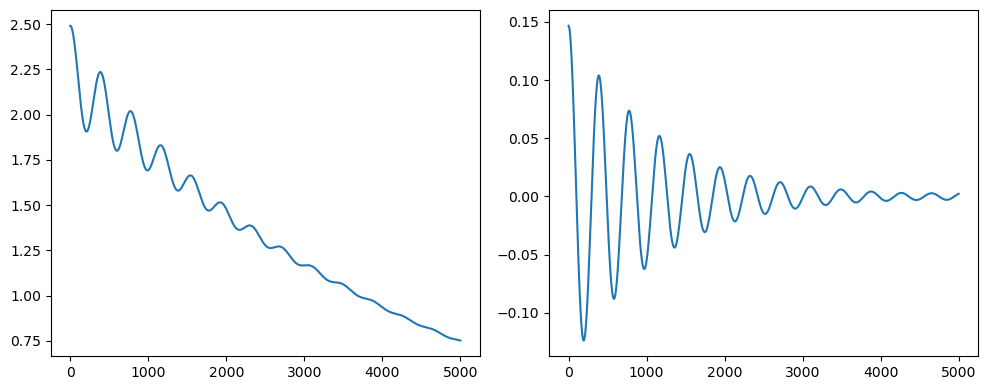

In [7]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].plot(xdu_corr)
axes[1].plot(vv_corr)
plt.tight_layout()
plt.show

In [9]:
print(xdu_corr[:10], vv_corr[:10], kernel_int[:10])

[2.49188403 2.49184878 2.49174305 2.49156687 2.49132028 2.49100335
 2.49061616 2.49015881 2.48963142 2.48903413] [0.14676732 0.14674799 0.14669002 0.14659348 0.14645849 0.14628513
 0.14607352 0.14582378 0.14553606 0.14521049] [ 0.          1.99608017  3.99037031  5.97893075  7.96527331  9.94590156
 11.92432934 13.89707183 15.86761799 17.83248676]
